In [1]:
%pip install opencv-python

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img =cv2.imread(r"D:\photo\IMG_20260717_125219_350.jpg")
print(type(img))

<class 'NoneType'>


In [3]:
from google.colab import files

uploaded = files.upload()

Saving IMG_20260717_125219_350.jpg to IMG_20260717_125219_350.jpg


In [7]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Get the uploaded filename automatically
filename = next(iter(uploaded))
print("Uploaded file:", filename)

# Read image directly from uploaded bytes
img = cv2.imdecode(
    np.frombuffer(uploaded[filename], np.uint8),
    cv2.IMREAD_COLOR
)

print("Type:", type(img))

if img is not None:
    print("Shape:", img.shape)
else:
    print("Image could not be decoded.")

Saving IMG_20251220_154244_461.webp to IMG_20251220_154244_461.webp
Uploaded file: IMG_20251220_154244_461.webp
Type: <class 'numpy.ndarray'>
Shape: (1536, 1152, 3)


In [8]:
print(img.shape)

(1536, 1152, 3)


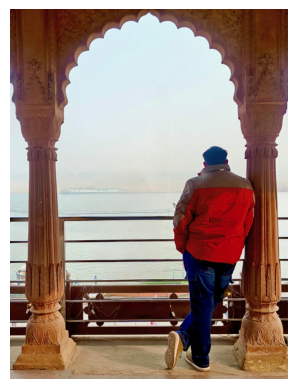

In [11]:
import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

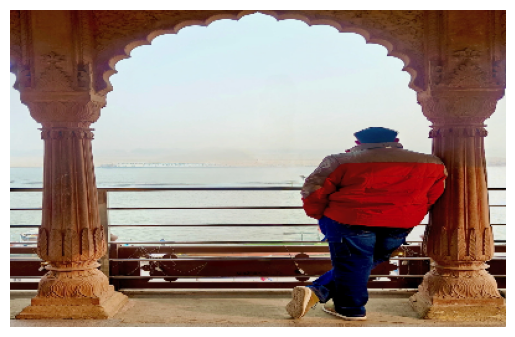

In [13]:
img_resize = cv2.resize(img, (400, 256))

plt.imshow(cv2.cvtColor(img_resize, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

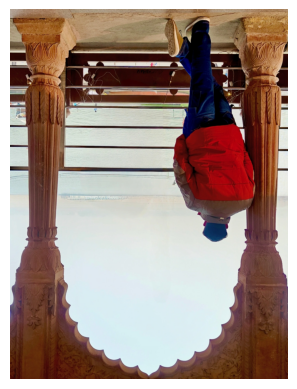

In [15]:
img_flip = cv2.flip(img, 0)

plt.imshow(cv2.cvtColor(img_flip, cv2.COLOR_BGR2RGB))

plt.axis("off")

plt.show()

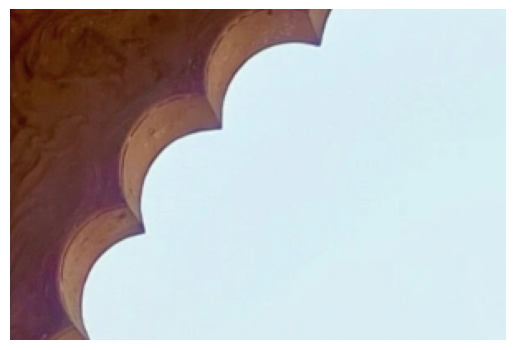

In [17]:
# Crop the image
img_crop = img[100:300, 200:500]

# Display cropped image
plt.imshow(cv2.cvtColor(img_crop, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [18]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 8.3 MB/s eta 0:00:00


Starting YOLO Object Counter...


<IPython.core.display.Javascript object>

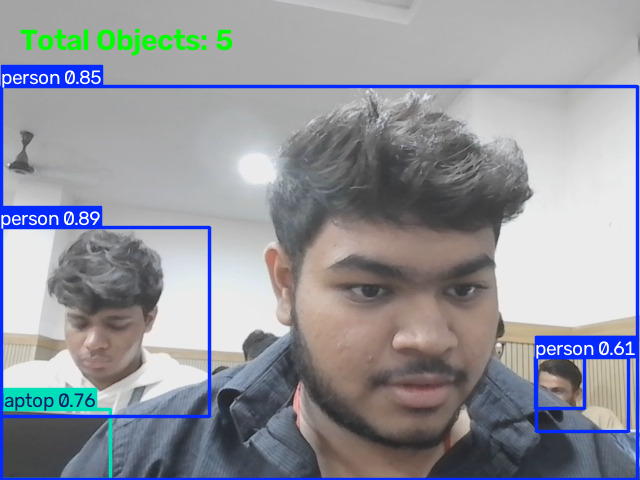

<IPython.core.display.Javascript object>

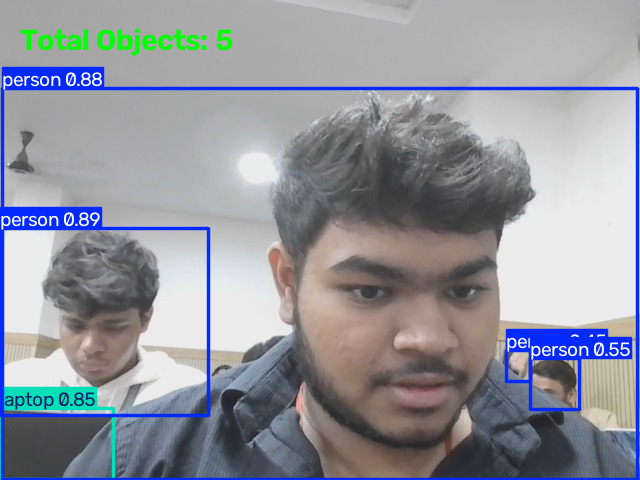

<IPython.core.display.Javascript object>

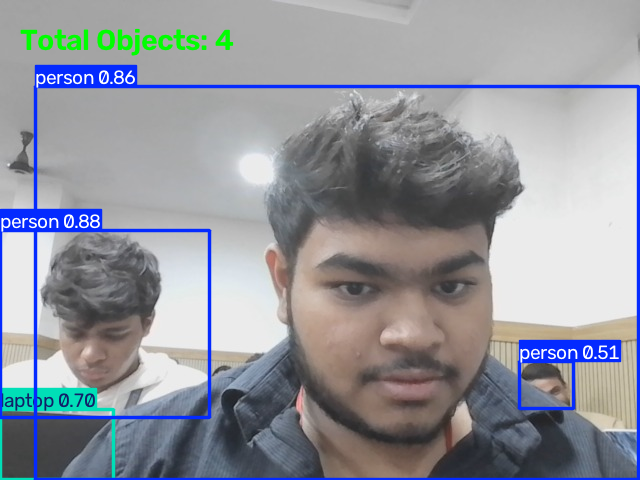

<IPython.core.display.Javascript object>

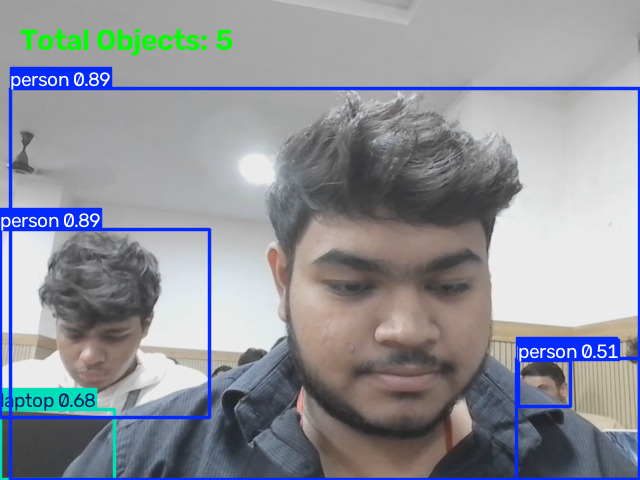

<IPython.core.display.Javascript object>

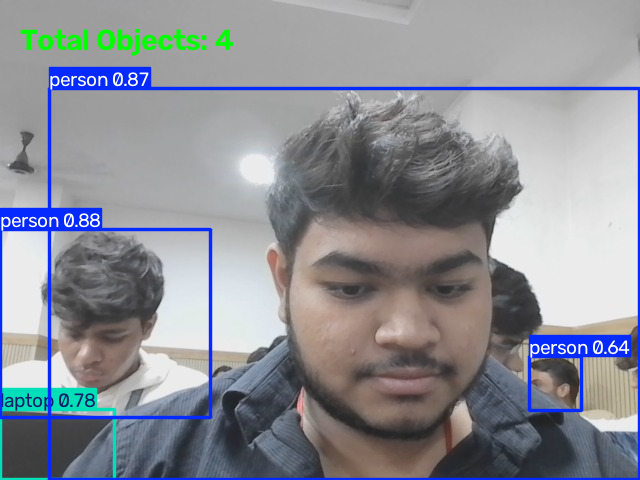

<IPython.core.display.Javascript object>

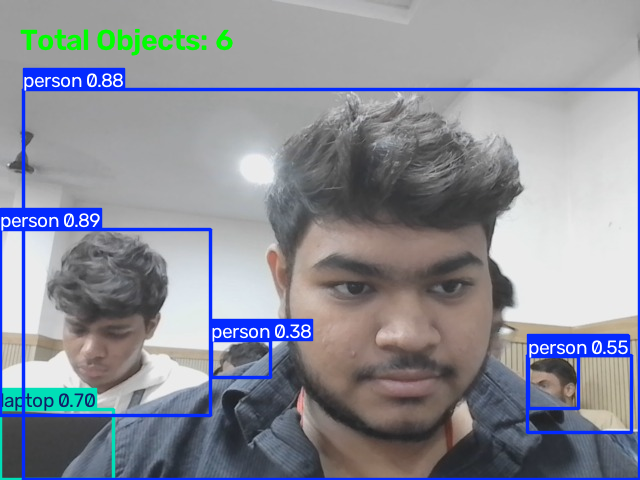

<IPython.core.display.Javascript object>

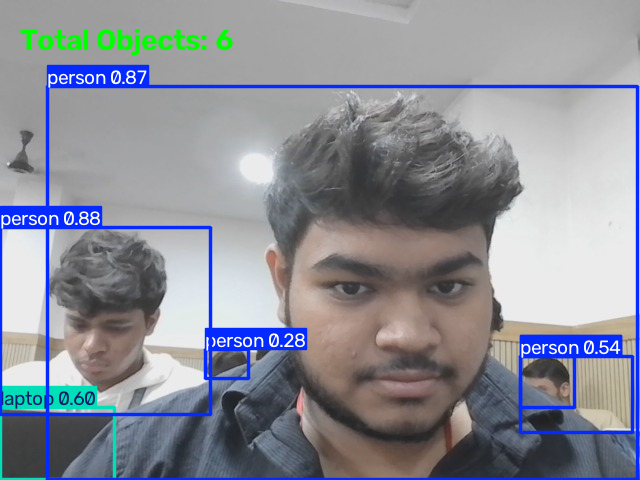

<IPython.core.display.Javascript object>

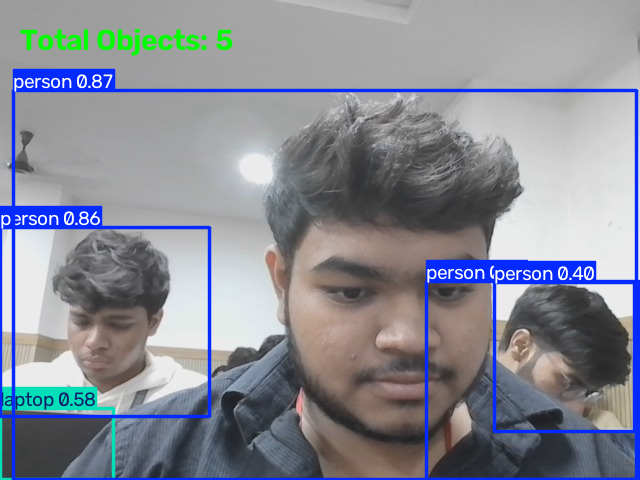

<IPython.core.display.Javascript object>

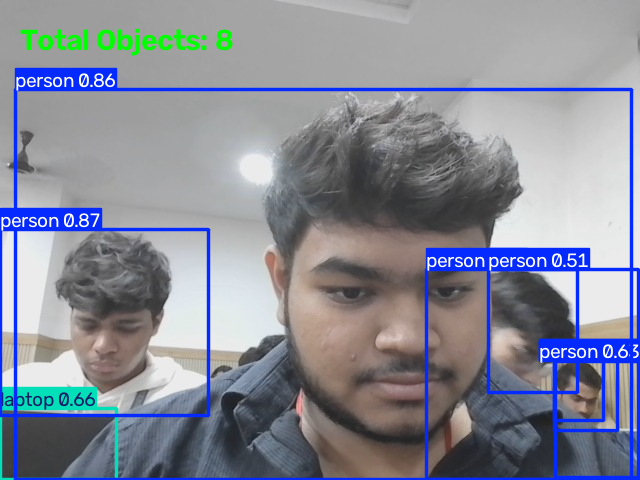

<IPython.core.display.Javascript object>

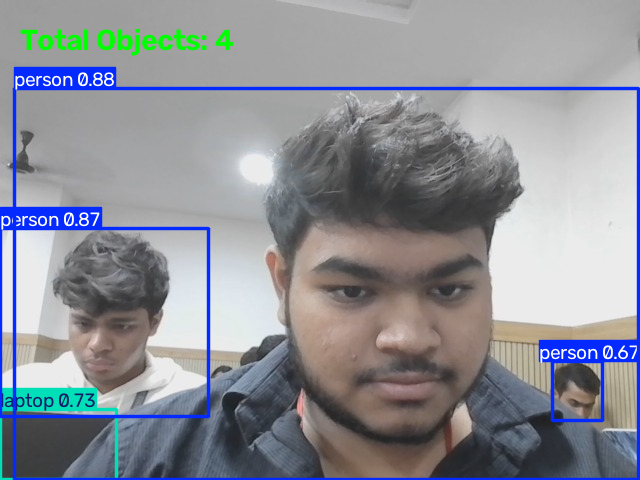

<IPython.core.display.Javascript object>

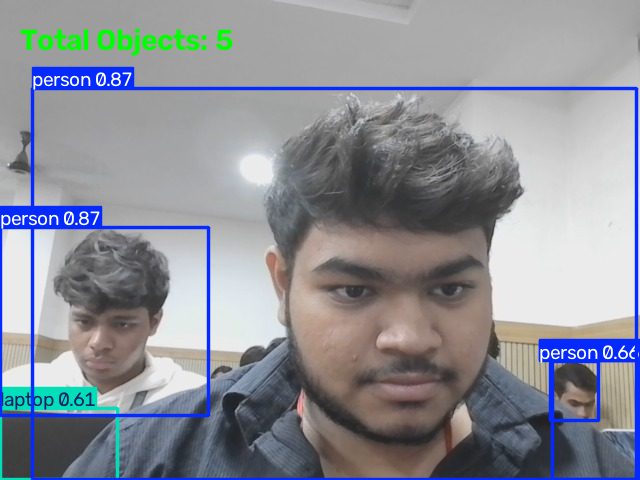

<IPython.core.display.Javascript object>

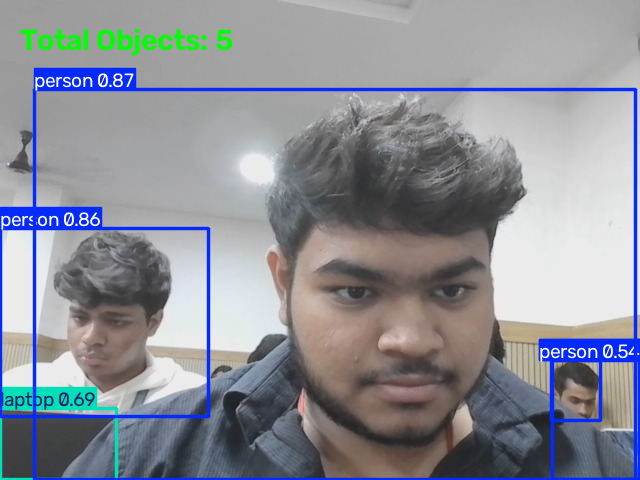

<IPython.core.display.Javascript object>

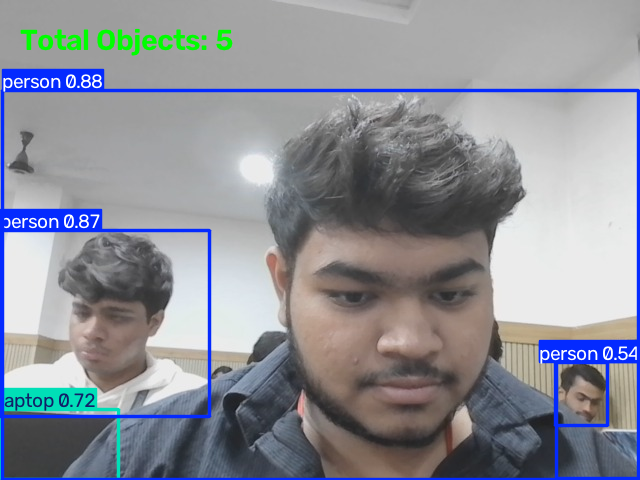

<IPython.core.display.Javascript object>

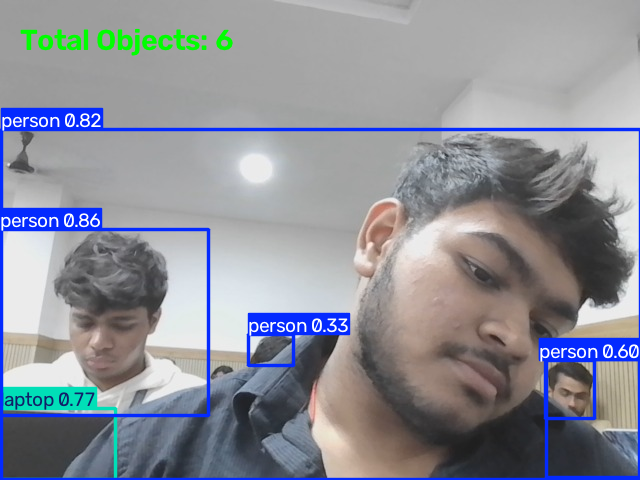

<IPython.core.display.Javascript object>

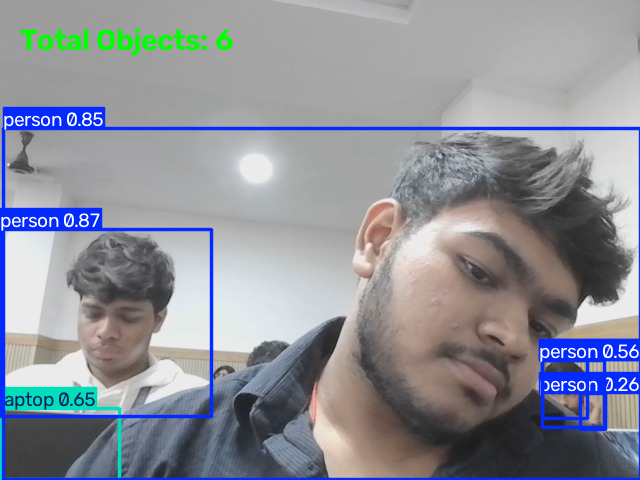

<IPython.core.display.Javascript object>

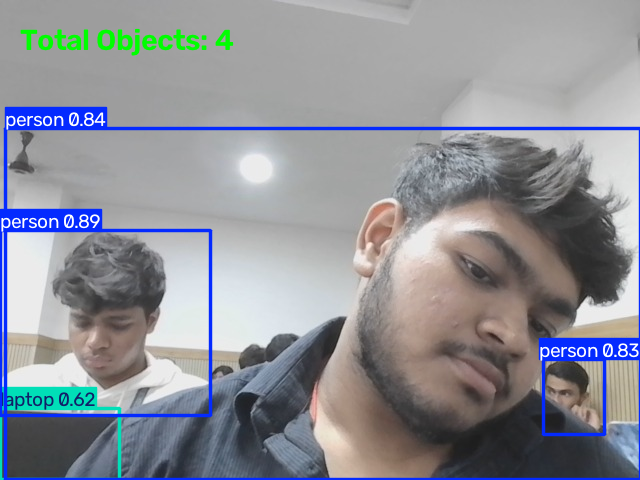

<IPython.core.display.Javascript object>

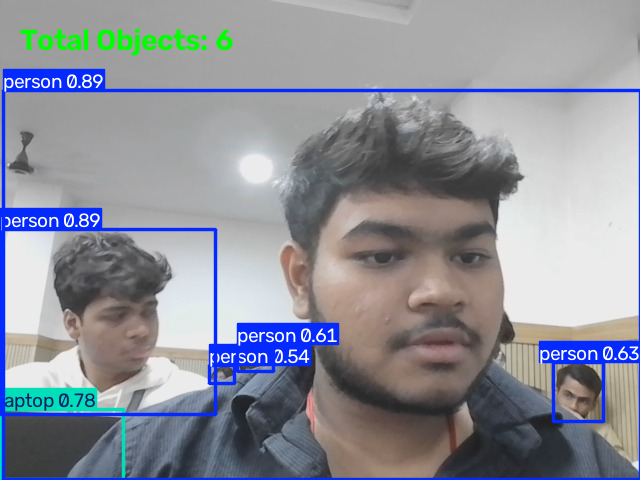

<IPython.core.display.Javascript object>

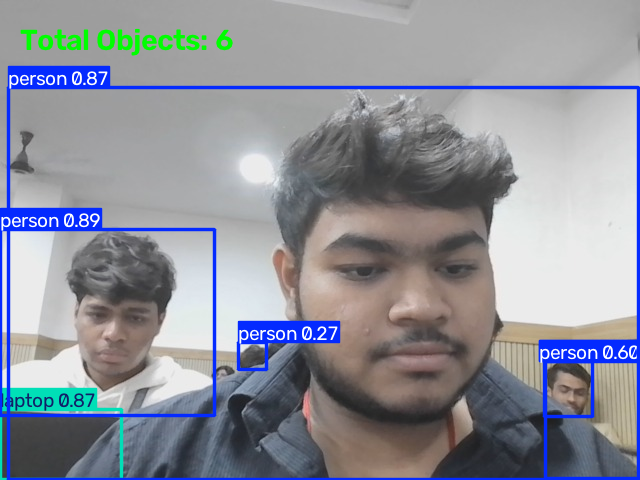

<IPython.core.display.Javascript object>

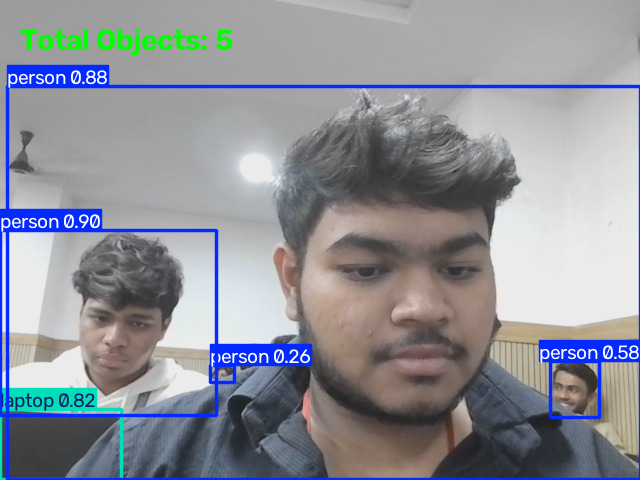

<IPython.core.display.Javascript object>

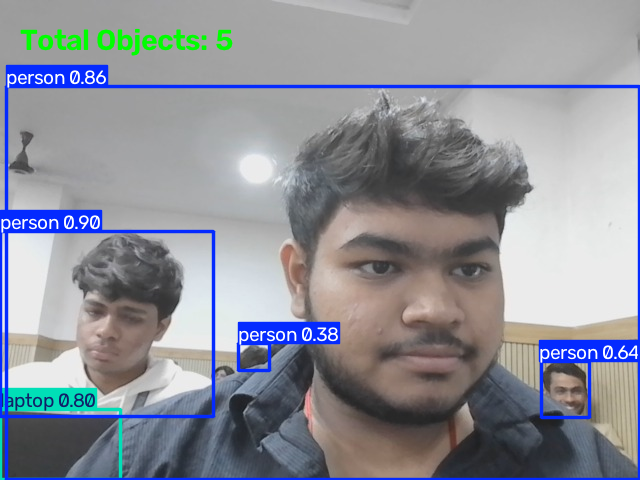

<IPython.core.display.Javascript object>

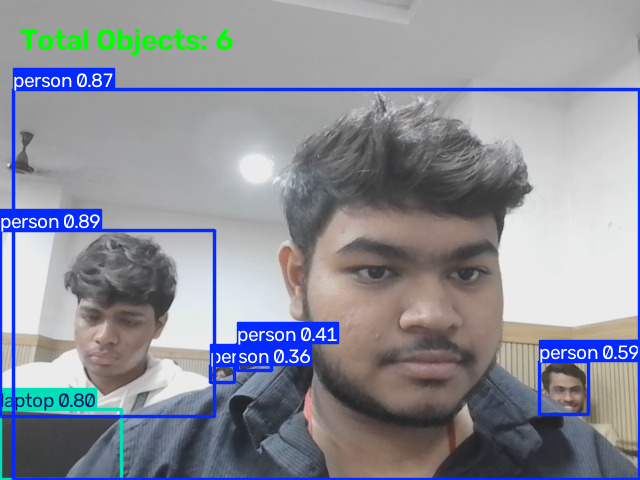

<IPython.core.display.Javascript object>

Camera stopped: NotAllowedError: Permission denied


In [29]:
import cv2
import numpy as np
from ultralytics import YOLO
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
from PIL import Image
import io

# Load YOLOv8 Nano model
model = YOLO("yolov8n.pt")

# JavaScript code to access webcam
def take_photo():
    js = Javascript('''
    async function takePhoto() {
        const div = document.createElement('div');

        const video = document.createElement('video');
        video.style.display = 'block';

        const stream = await navigator.mediaDevices.getUserMedia({
            video: true
        });

        document.body.appendChild(div);
        div.appendChild(video);

        video.srcObject = stream;
        await video.play();

        // Wait for camera to start
        await new Promise(resolve => setTimeout(resolve, 100));

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getVideoTracks()[0].stop();
        div.remove();

        return canvas.toDataURL('image/jpeg');
    }
    ''')

    display(js)
    data = eval_js("takePhoto()")

    binary = b64decode(data.split(',')[1])
    image = Image.open(io.BytesIO(binary))

    return cv2.cvtColor(
        np.array(image),
        cv2.COLOR_RGB2BGR
    )


# Capture and process frames
print("Starting YOLO Object Counter...")

for i in range(30):

    try:
        # Capture webcam image
        frame = take_photo()

        # YOLO detection
        results = model(frame, verbose=False)

        # Count detected objects
        detected_count = len(results[0].boxes)

        # Draw detection boxes
        annotated_frame = results[0].plot()

        # Add object count
        cv2.putText(
            annotated_frame,
            f"Total Objects: {detected_count}",
            (20, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2,
            cv2.LINE_AA
        )

        # Display frame
        display(
            Image.fromarray(
                cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
            )
        )

    except Exception as e:
        print("Camera stopped:", e)
        break

In [22]:
!pip install opencv-python-headless -q

In [28]:
import cv2
import numpy as np
import base64
from IPython.display import display, Javascript
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow

# ============================================================
# AIR CANVAS - GOOGLE COLAB
# ============================================================

# Blue color range in HSV
LOWER_COLOR = np.array([0, 0, 0])
UPPER_COLOR = np.array([180, 255, 80])

# JavaScript webcam setup
display(Javascript('''
async function startCamera() {

    const div = document.createElement('div');

    const video = document.createElement('video');
    video.width = 640;
    video.height = 480;
    video.autoplay = true;
    video.style.border = "2px solid black";

    const button = document.createElement('button');
    button.innerText = "STOP CAMERA";
    button.style.fontSize = "20px";
    button.style.padding = "10px";

    div.appendChild(video);
    div.appendChild(document.createElement('br'));
    div.appendChild(button);

    document.body.appendChild(div);

    const stream = await navigator.mediaDevices.getUserMedia({
        video: {
            width: 640,
            height: 480
        }
    });

    video.srcObject = stream;

    window.airCanvasStream = stream;
    window.airCanvasVideo = video;
    window.airCanvasStop = false;

    button.onclick = function() {
        window.airCanvasStop = true;
        stream.getTracks().forEach(track => track.stop());
        div.remove();
    };

    return true;
}

startCamera();
'''))

print("Starting Air Canvas...")
print("Show a BLUE object in front of the camera.")
print("Move it around to draw.")
print("Stop the camera using the button.")

<IPython.core.display.Javascript object>

Starting Air Canvas...
Show a BLUE object in front of the camera.
Move it around to draw.
Stop the camera using the button.
